# Profiling de RENAMU 2022

Este notebook perfila el archivo `Base_RENAMU_2022_f.csv` disponible en Bronze. El análisis se concentra en la estructura territorial y municipal del dataset, además de revisar su calidad con ocho dimensiones de evaluación.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('default')
pd.set_option('display.max_columns', 50)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RENAMU_PATH = PROJECT_ROOT / 'data' / 'bronze' / 'renamu'
RENAMU_FILE = RENAMU_PATH / 'Base_RENAMU_2022_f.csv'

print(f'Archivo principal: {RENAMU_FILE}')
print(f'Existe: {RENAMU_FILE.exists()}')

Archivo principal: /home/jovyan/work/data/bronze/renamu/Base_RENAMU_2022_f.csv
Existe: True


## Carga del dataset

RENAMU usa separador `;` y tiene muchísimas columnas. Se carga completo para preservar el contexto, pero el análisis se enfoca en un subconjunto de variables territoriales e institucionales clave para municipalidades.

In [2]:
renamu_df = pd.read_csv(RENAMU_FILE, sep=';', encoding='utf-8-sig', low_memory=False)
renamu_df.columns = [column.replace('﻿', '').strip() for column in renamu_df.columns]
renamu_df['source_file'] = RENAMU_FILE.name

key_columns = ['Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito', 'Tipomuni', 'source_file']
renamu_key_df = renamu_df[key_columns].copy()

for column in ['Año', 'Tipomuni']:
    renamu_key_df[column] = pd.to_numeric(renamu_key_df[column], errors='coerce')

for column in ['idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo']:
    renamu_key_df[column] = renamu_key_df[column].astype('string').str.replace('.0', '', regex=False).str.strip()

renamu_key_df.shape

(1150, 11)

## Exploración inicial

Se revisan dimensiones, columnas principales y una muestra de filas para entender qué representa cada registro. En RENAMU, cada fila corresponde a una municipalidad y muchas variables describen servicios, gestión y capacidad institucional.

In [3]:
display(renamu_key_df.head())
display(renamu_key_df.dtypes.to_frame('dtype').T)
renamu_key_df.isna().mean().sort_values(ascending=False).to_frame('missing_ratio')

,Año,idmunici,ccdd,ccpp,ccdi,Ubigeo,Departamento,Provincia,Distrito,Tipomuni,source_file
0,2022,10101,1,1,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,Base_RENAMU_2022_f.csv
1,2022,10102,1,1,2,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,Base_RENAMU_2022_f.csv
2,2022,10103,1,1,3,10103,AMAZONAS,CHACHAPOYAS,BALSAS,2,Base_RENAMU_2022_f.csv
3,2022,10104,1,1,4,10104,AMAZONAS,CHACHAPOYAS,CHETO,2,Base_RENAMU_2022_f.csv
4,2022,10105,1,1,5,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2,Base_RENAMU_2022_f.csv


,Año,idmunici,ccdd,ccpp,ccdi,Ubigeo,Departamento,Provincia,Distrito,Tipomuni,source_file
dtype,int64,string[python],string[python],string[python],string[python],string[python],object,object,object,int64,object


,missing_ratio
Año,0.0
idmunici,0.0
ccdd,0.0
ccpp,0.0
ccdi,0.0
Ubigeo,0.0
Departamento,0.0
Provincia,0.0
Distrito,0.0
Tipomuni,0.0


## Profiling descriptivo

Esta sección resume el dataset por departamento, provincia y tipo de municipalidad. También verifica el número de registros únicos por ubigeo e identificador municipal.

,Departamento,records
0,ANCASH,166
1,CAJAMARCA,127
2,AYACUCHO,119
3,JUNIN,115
4,CUSCO,112
5,AREQUIPA,109
6,HUANCAVELICA,100
7,AMAZONAS,84
8,APURIMAC,84
9,HUANUCO,84


,Tipomuni,records
0,2,1039
1,1,111


Ubigeos únicos: 1150
idmunici únicos: 1150


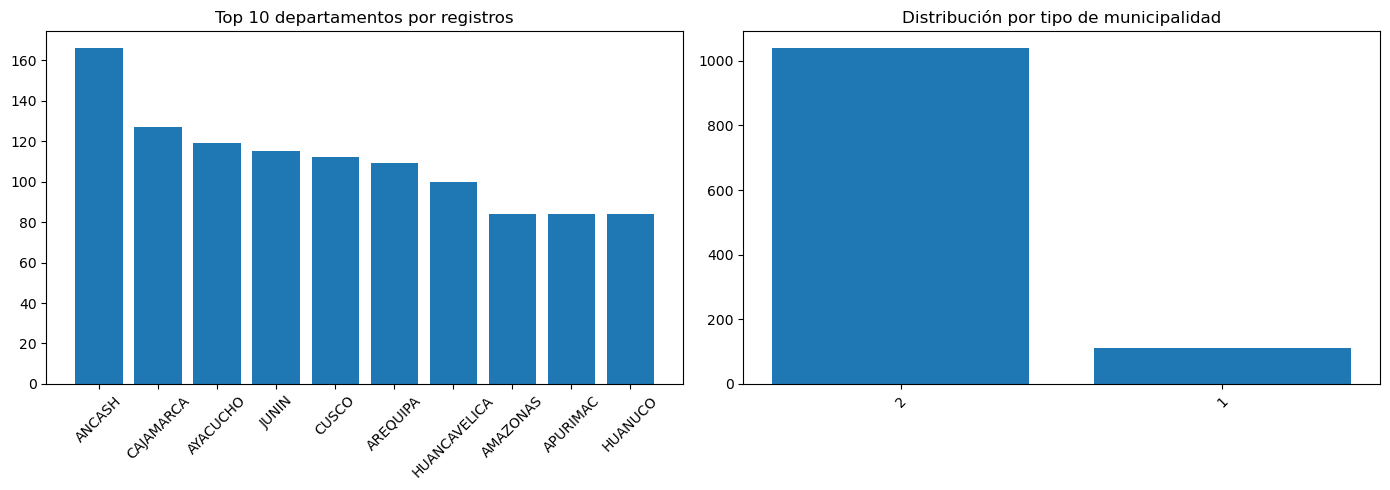

In [4]:
dept_counts = renamu_key_df['Departamento'].value_counts(dropna=False).reset_index()
dept_counts.columns = ['Departamento', 'records']
tipo_counts = renamu_key_df['Tipomuni'].value_counts(dropna=False).reset_index()
tipo_counts.columns = ['Tipomuni', 'records']

display(dept_counts.head(15))
display(tipo_counts)
print('Ubigeos únicos:', renamu_key_df['Ubigeo'].nunique(dropna=True))
print('idmunici únicos:', renamu_key_df['idmunici'].nunique(dropna=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(dept_counts.head(10)['Departamento'].astype(str), dept_counts.head(10)['records'])
axes[0].set_title('Top 10 departamentos por registros')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(tipo_counts['Tipomuni'].astype(str), tipo_counts['records'])
axes[1].set_title('Distribución por tipo de municipalidad')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Calidad de datos - 8 dimensiones

**A partir de esta sección comienza formalmente la evaluación de calidad de datos para RENAMU.**

Se revisan las ocho dimensiones sobre las columnas territoriales e identificadoras más importantes para el análisis municipal.

In [5]:
core_columns = ['Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']
missing_core_ratio = renamu_key_df[core_columns].isna().mean().mean()

duplicate_ratio = renamu_key_df.duplicated(subset=['idmunici']).mean()

valid_year_ratio = (renamu_key_df['Año'] == 2022).mean()
valid_ubigeo_ratio = renamu_key_df['Ubigeo'].fillna('').str.len().eq(6).mean()
valid_tipo_ratio = renamu_key_df['Tipomuni'].dropna().isin([1, 2, 3]).mean() if renamu_key_df['Tipomuni'].notna().any() else np.nan
validez_ratio = np.nanmean([valid_year_ratio, valid_ubigeo_ratio, valid_tipo_ratio])

expected_ubigeo = renamu_key_df['ccdd'].fillna('').str.zfill(2) + renamu_key_df['ccpp'].fillna('').str.zfill(2) + renamu_key_df['ccdi'].fillna('').str.zfill(2)
consistency_ratio = expected_ubigeo.eq(renamu_key_df['Ubigeo'].fillna('')).mean()

exactitud_ratio = renamu_key_df[['Departamento', 'Provincia', 'Distrito']].notna().all(axis=1).mean()
integrity_ratio = renamu_key_df[['idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']].notna().all(axis=1).mean()
actualidad_ratio = renamu_key_df['Año'].eq(2022).mean()
trazabilidad_ratio = renamu_key_df['source_file'].notna().mean()

quality_summary = pd.DataFrame([
    {'dimension': 'Completitud', 'metric': '1 - promedio de nulos en columnas territoriales clave', 'score': round(1 - missing_core_ratio, 4)},
    {'dimension': 'Unicidad', 'metric': '1 - proporción de duplicados por idmunici', 'score': round(1 - duplicate_ratio, 4)},
    {'dimension': 'Validez', 'metric': 'reglas de año, ubigeo y tipo municipal', 'score': round(validez_ratio, 4)},
    {'dimension': 'Consistencia', 'metric': 'Ubigeo coincide con ccdd+ccpp+ccdi', 'score': round(consistency_ratio, 4)},
    {'dimension': 'Exactitud', 'metric': 'presencia de nombres territoriales', 'score': round(exactitud_ratio, 4)},
    {'dimension': 'Integridad', 'metric': 'presencia conjunta de identificadores y geografía', 'score': round(integrity_ratio, 4)},
    {'dimension': 'Actualidad', 'metric': 'proporción de registros del año 2022', 'score': round(actualidad_ratio, 4)},
    {'dimension': 'Trazabilidad', 'metric': 'presencia de source_file', 'score': round(trazabilidad_ratio, 4)}
])

quality_summary

,dimension,metric,score
0,Completitud,1 - promedio de nulos en columnas territoriale...,1.0000
1,Unicidad,1 - proporción de duplicados por idmunici,1.0000
2,Validez,"reglas de año, ubigeo y tipo municipal",0.7368
3,Consistencia,Ubigeo coincide con ccdd+ccpp+ccdi,0.2104
4,Exactitud,presencia de nombres territoriales,1.0000
5,Integridad,presencia conjunta de identificadores y geografía,1.0000
6,Actualidad,proporción de registros del año 2022,1.0000
7,Trazabilidad,presencia de source_file,1.0000


## Hallazgos y conclusiones

La interpretación de RENAMU debe centrarse en su utilidad como dimensión o fuente de enriquecimiento municipal. Por eso se prioriza la lectura territorial y la coherencia de identificadores.

In [6]:
findings = [
    f'- RENAMU contiene {len(renamu_key_df):,} registros municipales y {renamu_df.shape[1]} columnas en total.'.replace(',', '.'),
    f'- Los departamentos representados son {renamu_key_df["Departamento"].nunique(dropna=True)}.',
    f'- La dimensión con menor score en esta evaluación es: {quality_summary.sort_values("score").iloc[0]["dimension"]}.',
    '- RENAMU es una base útil para enriquecer el análisis de municipalidades por ubigeo y capacidad institucional.'
]
display(Markdown('\n'.join(findings)))

- RENAMU contiene 1.150 registros municipales y 1369 columnas en total.
- Los departamentos representados son 12.
- La dimensión con menor score en esta evaluación es: Consistencia.
- RENAMU es una base útil para enriquecer el análisis de municipalidades por ubigeo y capacidad institucional.